# Visualize likelihood functions

In [3]:
from src.optimization import loglikelihood_thawed, loglikelihood_frozen
import numpy as np
import torch
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


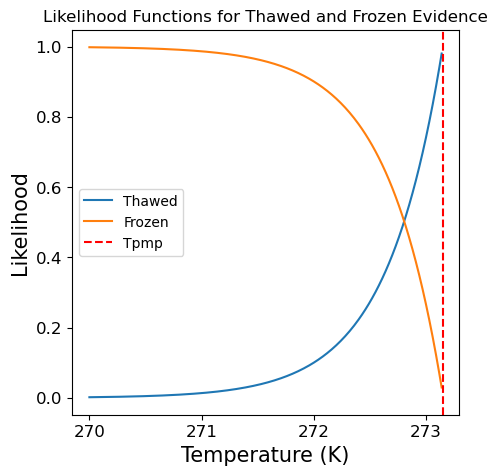

In [36]:
Tpmp = 273.15
dw = 1
df = 1
beta = 0.5

Tb = torch.arange(270, 273.15, 0.01)
beta_v = beta * torch.ones_like(Tb)
dw_v = dw * torch.ones_like(Tb)
df_v = df * torch.ones_like(Tb)
Tpmp_v = Tpmp * torch.ones_like(Tb)

# iterate 
likelihoods_thawed = []
likelihoods_frozen = []
for i in range(len(Tb)):
    likelihoods_thawed.append(torch.exp(loglikelihood_thawed(beta_v[i], Tb[i], Tpmp_v[i], dw_v[i])))
    likelihoods_frozen.append(torch.exp(loglikelihood_frozen(beta_v[i], Tb[i], Tpmp_v[i], df_v[i])))
likelihoods_thawed = torch.stack(likelihoods_thawed)
likelihoods_frozen = torch.stack(likelihoods_frozen)

# plot both lines in one plot
plt.figure(figsize=(5, 5))
plt.plot(Tb.numpy(), likelihoods_thawed.numpy(), label='Thawed')
plt.plot(Tb.numpy(), likelihoods_frozen.numpy(), label='Frozen')
plt.xlabel('Temperature (K)',fontsize=15)
plt.ylabel('Likelihood',fontsize=15)
plt.title('Likelihood Functions for Thawed and Frozen Evidence',fontsize=12)
# add a vertical line at Tpmp
plt.axvline(x=Tpmp, color='red', linestyle='--', label='Tpmp')
# make x tick sparse
plt.xticks(np.arange(270, 274, 1))
# make tick size larger
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend()
plt.savefig('figs/likelihood_functions.png')
plt.show()

In [ ]:
torch.arange()

tensor([230.])